In [4]:
import numpy as np
import maglab
import torch
import torch.nn.functional as F

def remove_background(phase, mask, ):
    # we need to compare the phase shift after removal of low-frequency signal, so we apply a gauss kernel filter on the images.
    gauss_kernel_size = 99
    sigma = maglab.preprocess.compute_sigma(gauss_kernel_size)
    kernel = maglab.preprocess.gaussian_kernel(gauss_kernel_size, sigma)
    kernel_groups = kernel.repeat(4, 1, 1, 1).cuda()
    phase_blurred = F.conv2d(phase, kernel_groups, groups=4, padding=gauss_kernel_size // 2)
    return (mask * (phase - phase_blurred))

def delta_phi(phi1, phi2):
    phi1 = phi1.detach().cpu().numpy()
    phi2 = phi2.detach().cpu().numpy()
    delta = np.sum(abs(phi1 - phi2))# / np.mean(abs(phi1))
    return delta

N = 206
dx = 1.06e-9
geo = maglab.geo.cylider(136, 111)
nx, ny, nz = geo.shape
Ms = 3.84e5
micro = maglab.Micro(nx, ny, nz, dx)

alphas1 = [0, 28, 44, 65]
alphas2 = [0, 28, 50, 65]
alphas3 = [0, 44, 58, 65]
alphas4 = [0, 50, 58, 65]
angles = [alphas1, alphas2, alphas3, alphas4]

paths_list = [
    r'..\recon-scripts\robustness\1[0,28,44,65]\loss1.6e+01_wphi1.0e+07\final.pth',
    r'..\recon-scripts\robustness\2[0,28,50,65]\loss1.6e+01_wphi1.0e+07\final.pth',
    r'..\recon-scripts\robustness\3[0,44,58,65]\loss1.6e+01_wphi1.0e+07\final.pth',
    r'..\recon-scripts\robustness\4[0,50,58,65]\loss1.6e+01_wphi1.0e+07\final.pth'
]

phasemapper = maglab.PhaseMapper(N, dx, rotation_padding=N).cuda()
with open(f'angles.txt', 'w') as f:
    f.write("Angles_Set, Lm, Lphi\n") 
    for idx, current_group_alphas in enumerate(angles):
        phaseset = maglab.dataset.PhaseSet()
        for alpha_val in current_group_alphas:
            try:
                phasemap_data = torch.load(f"..\\recon-scripts\\dataset\\dm3_refin\\refin_3dmask_pm\\phasemap_{alpha_val}.pth", weights_only=False)
                for item in phasemap_data:
                    data  = item['data'].transpose((1,0))
                    mask  = item['mask'].transpose((1,0))
                    alpha = -item['alpha']
                    phasemap = maglab.dataset.PhaseMap(data=data, mask=mask, alpha=alpha)
                phaseset.load(phasemap)
            except FileNotFoundError:
                print(f"Warning: File for alpha {alpha_val} not found.")
                continue
        phaseset.sort()

        phase_exeperiments = torch.stack([x.data for x in phaseset]).cuda()
        mask_exp = torch.stack([phasemap.mask for phasemap in phaseset]).cuda()
        extracted_alphas = [x.Euler[0] for x in phaseset]
        extracted_betas = [x.Euler[1] for x in phaseset]
        num_phase = len(phaseset)

        ws = [10**7]
        final_pth_path = f"{paths_list[idx]}"

        try:
            s = micro.load_state(final_pth_path)
            spin2 = s.get_spin().cuda()
            energy_density = s.get_energy_density(spin2)
            tot_energy = float(torch.sum(energy_density)) * s.dx**3

            phase_pred = torch.stack([phasemapper(spin2, 
                                                    alpha=extracted_alphas[i], 
                                                    beta=extracted_betas[i], 
                                                    Ms=Ms) 
                                            for i in range(num_phase)])

            phi_loss = delta_phi(remove_background(phase_exeperiments, mask_exp), 
                                 remove_background(phase_pred, mask_exp))
            
            Lm = tot_energy * 1e17
            Lphi = phi_loss

            f.write(f"{str(current_group_alphas)}, {Lm}, {Lphi}\n")
            f.flush() 

        except Exception as e:
            print(f"Error processing group {current_group_alphas}: {e}")
            f.write(f"{str(current_group_alphas)}, NaN, NaN\n")

print("所有数据处理完成，已保存到 angles.txt")

所有数据处理完成，已保存到 angles.txt


已保存中间计算文件: angles_processed.csv


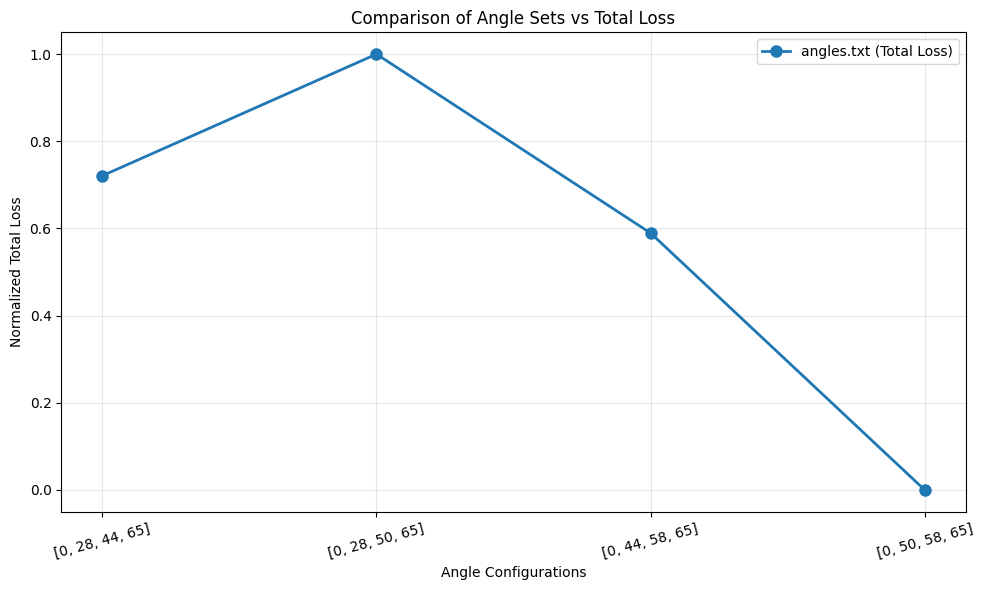

In [ ]:
import os
import numpy as np
import matplotlib.pyplot as plt
import csv

files = sorted([fn for fn in os.listdir('.') if fn.endswith('angles.txt')])

if not files:
    print("未找到 '*angles.txt' 文件")
else:
    def normalize(arr):
        arr = np.array(arr)
        mn = np.nanmin(arr)
        mx = np.nanmax(arr)
        if np.isclose(mx, mn):
            return np.zeros_like(arr)
        return (arr - mn) / (mx - mn)
    plt.figure(figsize=(10, 6))

    for fn in files:
        angle_labels = [] 
        Lm = []
        Lphi = []
        
        with open(fn, 'r', encoding='utf-8') as f:
            lines = f.readlines()

        for line in lines[1:]:
            line = line.strip()
            if not line: continue
            
            split_index = line.find(']')
            if split_index == -1: continue 
 
            label_str = line[:split_index+1]
            data_part = line[split_index+1:]
            parts = data_part.replace(',', ' ').split()
            
            if len(parts) < 2: continue
            
            try:
                lm_val = float(parts[0])
                lphi_val = float(parts[1])
                
                angle_labels.append(label_str)
                Lm.append(lm_val)
                Lphi.append(lphi_val)
            except ValueError:
                continue

        if not angle_labels:
            print(f"文件 {fn} 中没有有效数据")
            continue

        Lm = np.array(Lm, dtype=float)
        Lphi = np.array(Lphi, dtype=float)

        Lm_n = normalize(Lm)
        Lphi_n = normalize(Lphi)
        totloss_calc = normalize(Lm_n + Lphi_n)

        csv_filename = fn.replace('.txt', '_processed.csv')
        with open(csv_filename, 'w', newline='', encoding='utf-8') as csvfile:
            writer = csv.writer(csvfile)
            writer.writerow(['Angle_Set', 'Lm', 'Lphi', 'Total_Normalized_Loss'])
            for i in range(len(angle_labels)):
                writer.writerow([angle_labels[i], Lm[i], Lphi[i], totloss_calc[i]])
        print(f"已保存中间计算文件: {csv_filename}")

        x_indices = np.arange(len(angle_labels))

        plt.plot(x_indices, totloss_calc, '-o', label=f'{fn} (Total Loss)', linewidth=2, markersize=8)
        plt.xticks(x_indices, angle_labels, rotation=15)

    plt.title('Comparison of Angle Sets vs Total Loss')
    plt.xlabel('Angle Configurations')
    plt.ylabel('Normalized Total Loss')
    plt.grid(True, alpha=0.3)
    plt.legend()
    plt.tight_layout()
    plt.show()